Импорт необходимых модулей:

In [56]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess
import shutil

### Генерируем точки + строим графики и изображения

In [57]:
#sample_size_sqrt = 3163
sample_size_sqrt = 3163
sample_size = sample_size_sqrt * sample_size_sqrt

isClassic = False

classic = ''
if isClassic:
    classic = ' --classic'

print(sample_size)

10004569


Build через CMake & Запуск генерации точек

In [58]:
if ( os.path.exists('../bin/') ):
    shutil.rmtree('../bin/')

In [59]:
if platform.system() == 'Windows':
    subprocess.run(['cmake', '..', '-B..\\bin\\', '-DCMAKE_BUILD_TYPE=Release', '-DCMAKE_TOOLCHAIN_FILE=C:\\vcpkg\\scripts\\buildsystems\\vcpkg.cmake', '-GNinja'])
    subprocess.run(['cmake', '--build', '..\\bin\\', '--config=release'])

    out = subprocess.check_output( "..\\bin\\GeneratorResearch.exe -g xor-shift-64 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\GeneratorResearch.exe -g xor-shift-1024 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\GeneratorResearch.exe -g mt19937 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\GeneratorResearch.exe -g rand16 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\GeneratorResearch.exe -g rand32 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)
else:
    subprocess.run(['cmake', '..', '-B../bin/', '-DCMAKE_BUILD_TYPE=Release', '-DCMAKE_TOOLCHAIN_FILE=/vcpkg/scripts/buildsystems/vcpkg.cmake', '-GNinja'])
    subprocess.run(['cmake', '--build', '../bin/', '--config=release'])

    out = subprocess.check_output( "../bin/GeneratorResearch -g xor-shift-64 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "../bin/GeneratorResearch -g xor-shift-1024 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "../bin/GeneratorResearch -g mt19937 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "../bin/GeneratorResearch -g rand16 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "../bin/GeneratorResearch -g rand32 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

-- The C compiler identification is GNU 12.2.1
-- The CXX compiler identification is GNU 12.2.1
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Boost: /vcpkg/installed/x64-linux/include (found suitable version "1.80.0", minimum required is "1.76.0") found components: program_options filesystem 
-- Looking for CL_VERSION_3_0
-- Looking for CL_VERSION_3_0 - not found
-- Looking for CL_VERSION_2_2
-- Looking for CL_VERSION_2_2 - found
-- Found OpenCL: /vcpkg/installed/x64-linux/lib/libOpenCL.a (found version "2.2") 
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE 

-- GIT_COMMIT_HASH: 7e243562b0e1a21b75b092f28bccfa7e2a5a2eee
-- Doxygen build started


-- Configuring done
-- Generating done
-- Build files have been written to: /home/joel/Development/test/nikulin/bin
[1/47] Generating kernel_boost.cl.c
[2/47] Building C object random/CMakeFiles/random.dir/src/rand.c.o
[3/47] Building C object random/CMakeFiles/random.dir/src/context.c.o
[4/47] Building C object random/CMakeFiles/random.dir/src/converter.c.o
[5/47] Building C object random/CMakeFiles/random.dir/src/xor_shift.c.o
[6/47] Building C object random/CMakeFiles/random.dir/src/buffer_placeholder.c.o
[7/47] Linking C shared library librandom.so.1.0.0
[8/47] Creating library symlink librandom.so.1 librandom.so
[9/47] Building C object CMakeFiles/modules.dir/cmake_pch.h.gch
[10/47] -- Generating API documentation with Doxygen
The selected output language "russian" has not been updated
since release 1.8.15.  As a result some sentences may appear in English.

Doxygen version used: 1.9.5
Notice: Output directory '/home/joel/Development/test/nikulin/bin/docs/' does not exist. I have 

Подгружаем сгенерированные выборки:

In [60]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand16     = pd.read_csv("rand16.csv")
rand32     = pd.read_csv("rand32.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [61]:
x64.head()

,randoms
0,0.186370
1,0.770335
2,0.150725
3,0.187713
4,0.085245


Описательная статистика:

In [62]:
x64['randoms'].describe()

count    1.000457e+07
mean     4.998966e-01
std      2.887112e-01
min      2.994290e-09
25%      2.498240e-01
50%      4.998240e-01
75%      7.500770e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

In [63]:
bins = 1000
bins_ranges = np.arange(start=0, stop=1, step=1 / bins)

In [64]:
hist_x64, bins_ranges = np.histogram(x64.to_numpy(), bins_ranges)
hist_x1024, bins_ranges = np.histogram(x1024.to_numpy(), bins_ranges)
hist_mt19937, bins_ranges = np.histogram(mt19937.to_numpy(), bins_ranges)
hist_rand16, bins_ranges = np.histogram(rand16.to_numpy(), bins_ranges)
hist_rand32, bins_ranges = np.histogram(rand32.to_numpy(), bins_ranges)

(9568.0, 10273.0)

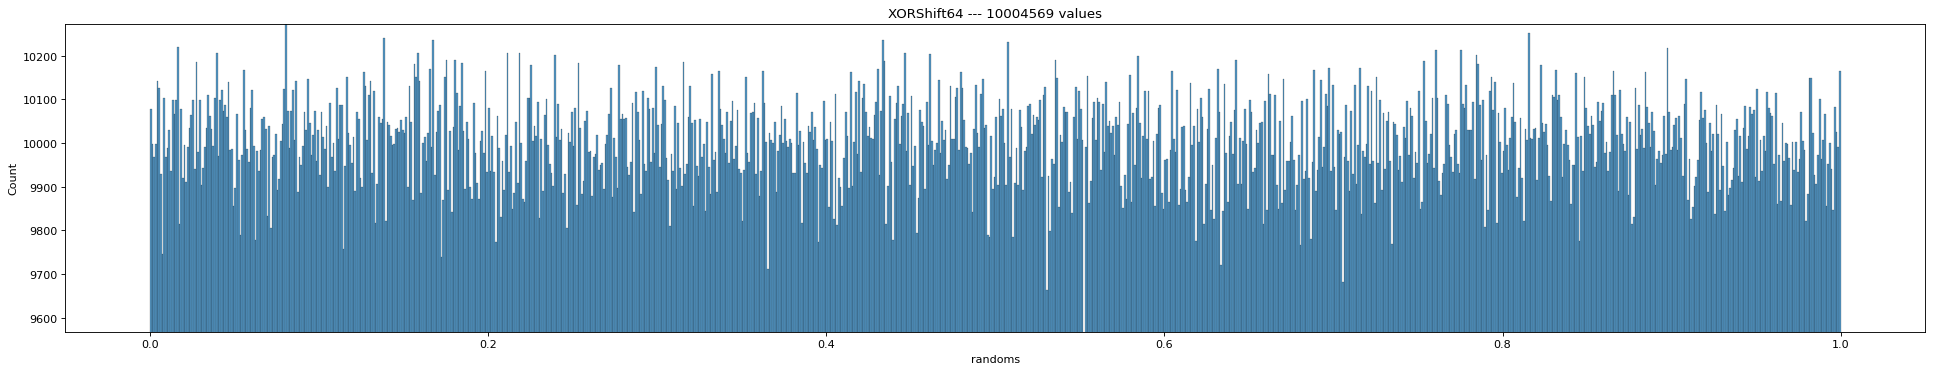

In [65]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=bins).set(title='XORShift64 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_x64), top=np.max(hist_x64))

In [66]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [67]:
data.shape

(10004569, 1)

In [68]:
data = data.reshape(sample_size_sqrt, sample_size_sqrt)
print(data)

[[ 47 196  38 ... 187  94 241]
 [ 33  73 219 ...  55  63 109]
 [104 153  88 ... 157 206 246]
 ...
 [159  78  46 ... 175 194 252]
 [  6  90 189 ... 212 108 185]
 [232 194 205 ...  19 215 248]]


In [69]:
data.shape

(3163, 3163)

In [70]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9744.0, 10433.0)

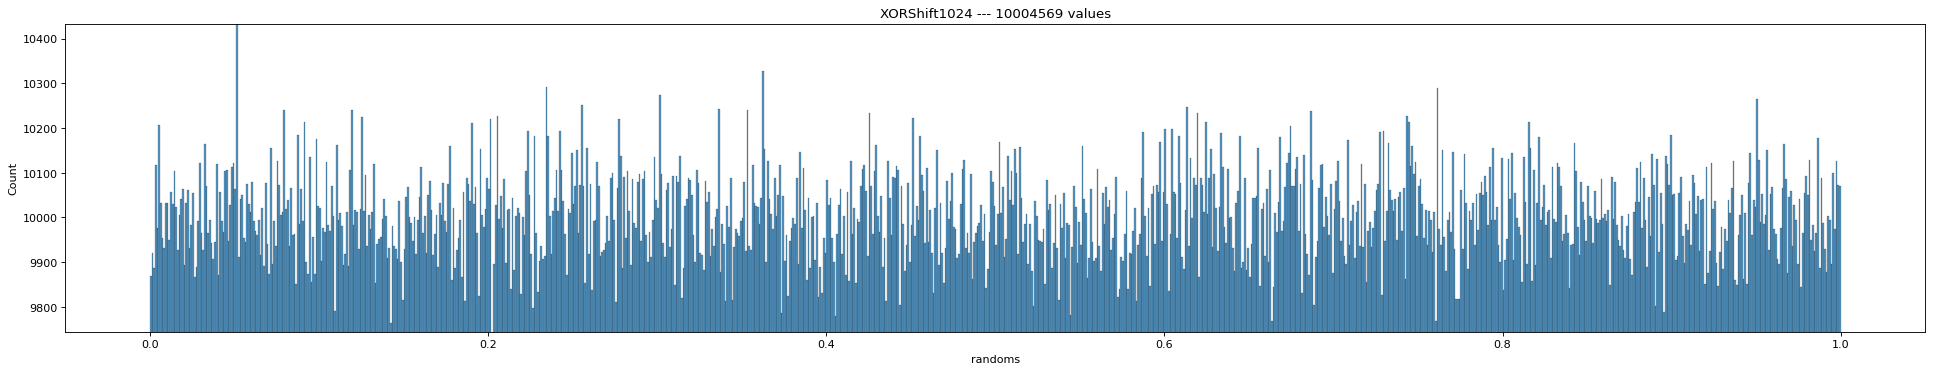

In [71]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=bins).set(title='XORShift1024 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_x1024), top=np.max(hist_x1024))

In [72]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [73]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9657.0, 10271.0)

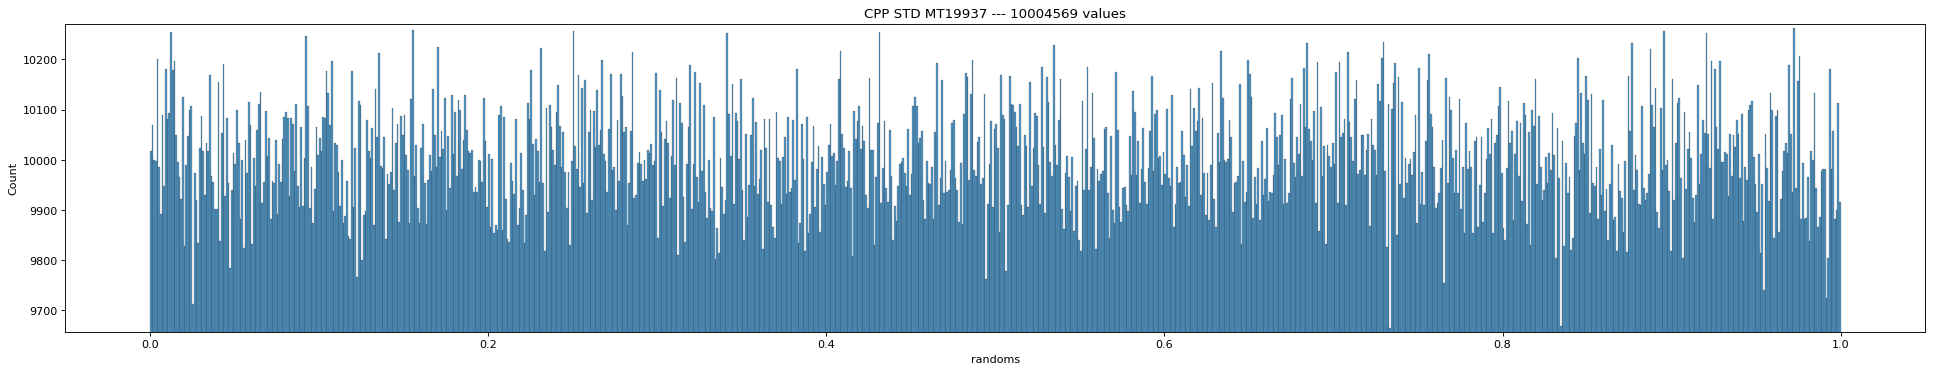

In [74]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=bins).set(title='CPP STD MT19937 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_mt19937), top=np.max(hist_mt19937))

In [75]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [76]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(0.0, 1000457.0)

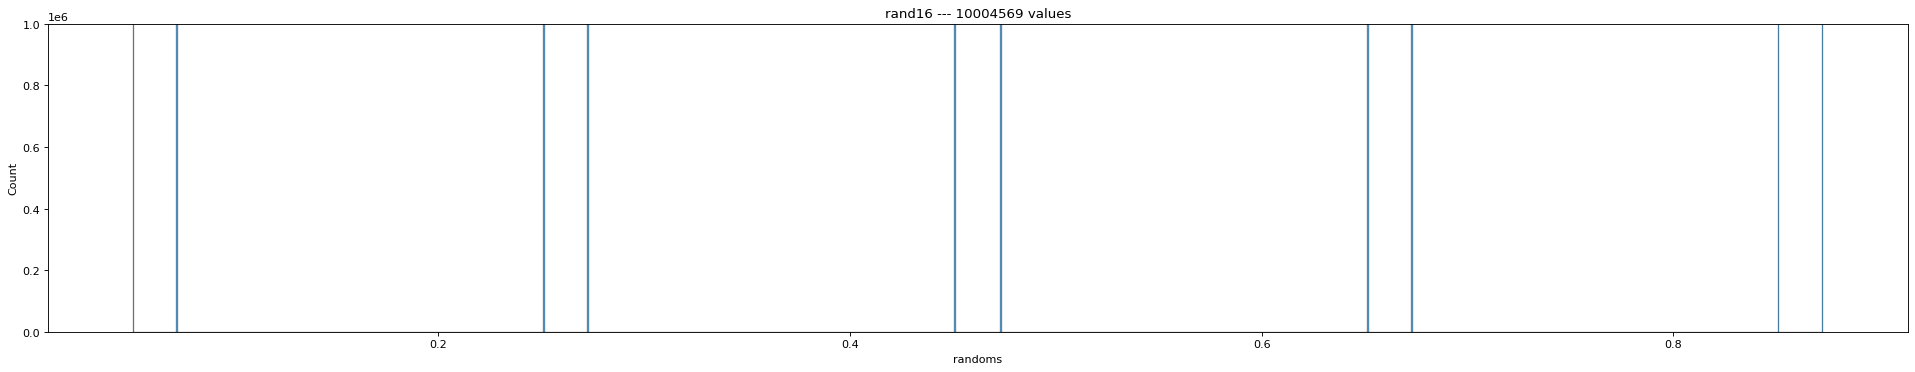

In [77]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand16, x="randoms", bins=bins).set(title='rand16 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_rand16), top=np.max(hist_rand16))

In [78]:
data = 255 * np.array(rand16)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [79]:
img = Image.fromarray(data, 'L')
img.save('rand16_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(0.0, 20419.0)

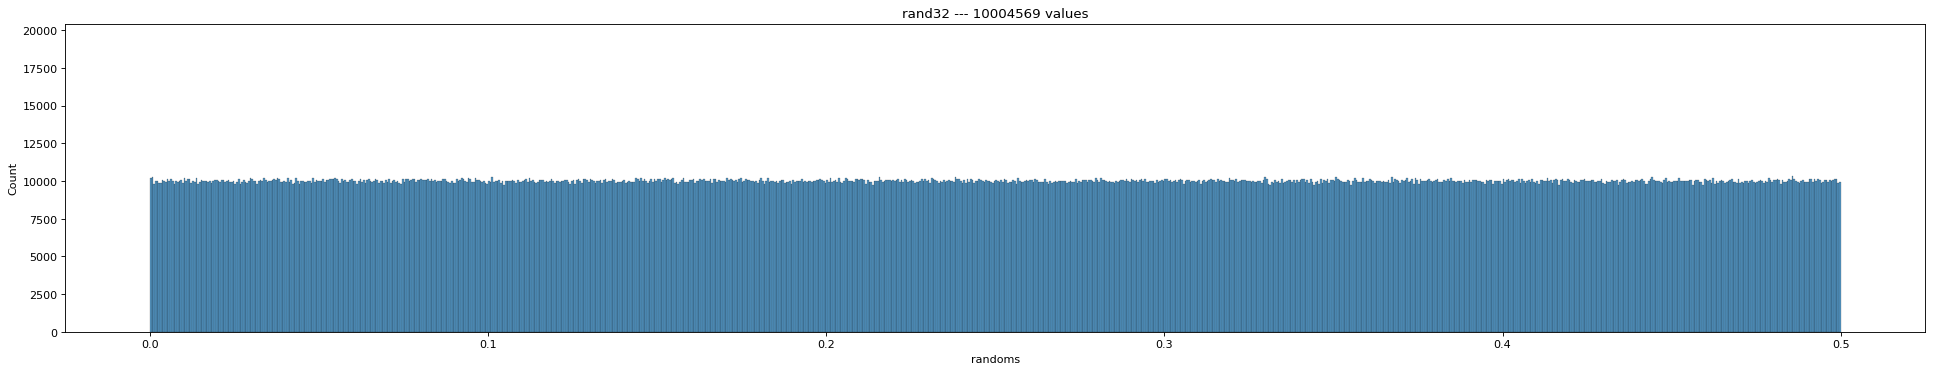

In [80]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand32, x="randoms", bins=bins).set(title='rand32 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_rand32), top=np.max(hist_rand32))

In [81]:
data = 255 * np.array(rand32)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [82]:
img = Image.fromarray(data, 'L')
img.save('rand32_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [83]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [84]:
#type = 'by-element'
type = 'by-sum'

Метрика качества для XorShift64:

In [85]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.18637  ]
 [0.770335 ]
 [0.150725 ]
 ...
 [0.0782667]
 [0.845942 ]
 [0.974173 ]]
XorShift64 Quality: 0.9997932115110655


Метрика качества для XorShift1024:

In [86]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.649305]
 [0.343038]
 [0.279442]
 ...
 [0.135258]
 [0.113102]
 [0.463897]]
XorShift1024 Quality: 0.9999201007474492


Метрика качества для MT19937:

In [87]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.434985]
 [0.791735]
 [0.823811]
 ...
 [0.673067]
 [0.233697]
 [0.694071]]
MT19937 Quality: 0.9998722298673464


In [88]:
quality = get_quality_of_values(rand16, type)
print(f'rand16() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.851325 ]
 [0.472896 ]
 [0.651325 ]
 ...
 [0.251341 ]
 [0.872881 ]
 [0.0513406]]
rand16() Quality: 0.9242244302427235


In [89]:
quality = get_quality_of_values(rand32, type)
print(f'rand32() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.0186811]
 [0.109686 ]
 [0.494376 ]
 ...
 [0.14408  ]
 [0.494816 ]
 [0.404082 ]]
rand32() Quality: 0.49991645060406986


### Среднеквадратичное отклонение

In [90]:
size = len(hist_x64)
avg = np.mean(hist_x64)
max = np.max(hist_x64)
min = np.min(hist_x64)

# print(len(bins))
# print(avg)
# print(size)

RMSD = 0
for h in hist_x64:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift64 = {NRMSD}')

Root mean square deviation for XorShift64 = 0.13933325818662967


In [91]:
size = len(hist_x1024)
avg = np.mean(hist_x1024)
max = np.max(hist_x1024)
min = np.min(hist_x1024)

RMSD = 0
for h in hist_x1024:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift1024 = {NRMSD}')

Root mean square deviation for XorShift1024 = 0.14083171530878455


In [92]:
size = len(hist_mt19937)
avg = np.mean(hist_mt19937)
max = np.max(hist_mt19937)
min = np.min(hist_mt19937)

RMSD = 0
for h in hist_mt19937:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for MT19937 = {NRMSD}')

Root mean square deviation for MT19937 = 0.16408094904719328


In [93]:
size = len(hist_rand16)
avg = np.mean(hist_rand16)
max = np.max(hist_rand16)
min = np.min(hist_rand16)

RMSD = 0
for h in hist_rand16:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand16() = {NRMSD}')

Root mean square deviation for rand16() = 0.09954801720051458


In [94]:
size = len(hist_rand32)
avg = np.mean(hist_rand32)
max = np.max(hist_rand32)
min = np.min(hist_rand32)

RMSD = 0
for h in hist_rand32:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand32() = {NRMSD}')

Root mean square deviation for rand32() = 0.4899860854452883
